# Multitask Stochastic D-Optimal Design

This notebook verifies the corrected stochastic objective and basis construction, then runs the experiment on the real `AmesHousing.csv` dataset. The main update is the corrected block-diagonal basis matrix `\Phi(\lambda)` with `q` basis functions per design point.

## 1. Verification of the corrected basis setup

Let $d$ be the number of design points and let $q$ be the number of basis functions used for each component of $\theta^*(\lambda)$. We sample one shared set of $q$ random directions in $\mathbb{R}^S$, take their inner products with $\lambda$, and apply a softmax across those $q$ values. This gives a basis vector
$$
\phi(\lambda) \in \mathbb{R}^q,
\qquad
\sum_{k=1}^q \phi_k(\lambda)=1,
\qquad
\phi_k(\lambda) > 0.
$$
The same basis vector is reused for every design point, so each row block of $\Phi(\lambda)$ uses the same $q$ basis values while retaining its own coefficient block $\beta_i$.

Stacking these componentwise bases gives the corrected block-diagonal matrix
$$
\Phi(\lambda) \in \mathbb{R}^{d \times qd},
$$
with one $1 \times q$ block per row. Writing
$$
\beta = (\beta_1^\top, \dots, \beta_d^\top)^\top,
\qquad
\beta_i \in \mathbb{R}^q,
\qquad
p = qd,
$$
we obtain the raw positive weights
$$
\alpha_i(\lambda,\beta) = \phi(\lambda)^\top \beta_i.
$$

Because this corrected block-diagonal parameterization does not preserve the simplex automatically, the notebook converts the raw positive weights into a feasible design by normalizing them:
$$
\theta_i(\lambda,\beta) = \frac{\alpha_i(\lambda,\beta)}{\sum_{r=1}^d \alpha_r(\lambda,\beta)}.
$$
Thus $\theta(\lambda,\beta) \in \Delta_d$.

For task $s$,
$$
M^{(s)}(\theta)=X^{(s)\top}\operatorname{Diag}(\theta)X^{(s)}.
$$
The stochastic objective remains
$$
F_\gamma(\beta)
=
\mathbb{E}_{\lambda\sim\mathbb{P}_\lambda}\left[
\sum_{s=1}^S \lambda_s\big(-\log\det M^{(s)}(\theta(\lambda,\beta))\big)
\right] + \gamma\psi(\beta),
\qquad
\psi(\beta) = -\sum_{j=1}^{qd}\log \beta_j.
$$

The task-level matrix must still be indexed correctly:
$$
A^{(s)}(\lambda,\beta)
:=
X^{(s)}\big(M^{(s)}(\theta(\lambda,\beta))\big)^{-1}X^{(s)\top}.
$$
If
$$
g_\theta = \nabla_\theta \sum_{s=1}^S \lambda_s\big(-\log\det M^{(s)}(\theta)\big),
$$
then
$$
(g_\theta)_i = -\sum_{s=1}^S \lambda_s\,\operatorname{diag}(A^{(s)}(\lambda,\beta))_i.
$$
Since $\theta = \alpha / (\mathbf{1}^\top \alpha)$, the chain rule gives
$$
\nabla_\alpha f = \frac{g_\theta - (\theta^\top g_\theta)\mathbf{1}}{\mathbf{1}^\top\alpha},
$$
and therefore the gradient with respect to the block coefficients is
$$
\frac{\partial f}{\partial \beta_{ik}} = \phi_{ik}(\lambda)\,(\nabla_\alpha f)_i.
$$

The mirror-descent update with the log-barrier reference function is unchanged in form:
$$
\beta_{t+1}
=
\arg\min_{\beta\in\Delta_{qd}}
\Big\{\eta\nabla f_\gamma(\beta_t,\lambda_t)^\top(\beta-\beta_t)+D_\psi(\beta,\beta_t)\Big\},
$$
which again reduces to the scalar root solve
$$
\beta_{t+1,j} = \frac{1}{v_{t,j}+\xi_t},
\qquad
\sum_{j=1}^{qd}\frac{1}{v_{t,j}+\xi_t}=1.
$$

As before, I use
$$
\lambda \sim \operatorname{Dirichlet}(1,\ldots,1).
$$

In [72]:
import math
import numpy as np
import pandas as pd
from IPython.display import SVG, display

SEED = 7
rng = np.random.default_rng(SEED)

In [73]:
# Problem dimensions and optimization hyperparameters.
q = 20
ridge = 1e-5
gamma = 1e-2
eta = .5/(1 + gamma)
T = 1000
n_eval = 30

task_names = ["SalePrice", "GrLivArea", "GarageArea", "TotalBsmtSF"]
S = len(task_names)

In [74]:
# Load the real Ames Housing data and keep the numeric columns needed by the four tasks.
raw = pd.read_csv("AmesHousing.csv")

column_map = {
    "SalePrice": "SalePrice",
    "Overall Qual": "OverallQual",
    "Gr Liv Area": "GrLivArea",
    "Garage Cars": "GarageCars",
    "Total Bsmt SF": "TotalBsmtSF",
    "Year Built": "YearBuilt",
    "TotRms AbvGrd": "TotRmsAbvGrd",
    "Bedroom AbvGr": "BedroomAbvGr",
    "Full Bath": "FullBath",
    "1st Flr SF": "FirstFlrSF",
    "2nd Flr SF": "SecondFlrSF",
    "Garage Area": "GarageArea",
    "Lot Area": "LotArea",
    "Fireplaces": "Fireplaces",
    "Overall Cond": "OverallCond",
}

selected = raw[list(column_map)].rename(columns=column_map).copy()
selected = selected.apply(pd.to_numeric, errors="coerce")

missing_before = selected.isna().sum().sort_values(ascending=False)
selected = selected.fillna(selected.median(numeric_only=True))
selected = selected.dropna().reset_index(drop=True)
full_clean_n = len(selected)
# if subsample dataset
# selected = selected.sample(n=200, random_state=SEED).reset_index(drop=True)

d = len(selected)
p = q * d

print(f"Rows after preprocessing before subsampling: {full_clean_n}")
print(f"Rows used in the experiment: {d}")
print(f"Basis dimension q = {q}")
print(f"Parameter dimension p = qd = {p}")
print("Missing values before imputation on selected columns:")
print(missing_before[missing_before > 0])
selected.head()


Rows after preprocessing before subsampling: 2930
Rows used in the experiment: 2930
Basis dimension q = 20
Parameter dimension p = qd = 58600
Missing values before imputation on selected columns:
GarageCars     1
TotalBsmtSF    1
GarageArea     1
dtype: int64


,SalePrice,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,TotRmsAbvGrd,BedroomAbvGr,FullBath,FirstFlrSF,SecondFlrSF,GarageArea,LotArea,Fireplaces,OverallCond
0,215000,6,1656,2.0,1080.0,1960,7,3,1,1656,0,528.0,31770,2,5
1,105000,5,896,1.0,882.0,1961,5,2,1,896,0,730.0,11622,0,6
2,172000,6,1329,1.0,1329.0,1958,6,3,1,1329,0,312.0,14267,0,6
3,244000,7,2110,2.0,2110.0,1968,8,3,2,2110,0,522.0,11160,2,5
4,189900,5,1629,2.0,928.0,1997,6,3,2,928,701,482.0,13830,1,5


In [75]:
# Task-specific design matrices built from the real data.
task_features = {
    "SalePrice": ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"],
    "GrLivArea": ["TotRmsAbvGrd", "BedroomAbvGr", "FullBath", "FirstFlrSF", "SecondFlrSF"],
    "GarageArea": ["GarageCars", "OverallQual", "YearBuilt", "LotArea", "Fireplaces"],
    "TotalBsmtSF": ["LotArea", "YearBuilt", "FirstFlrSF", "OverallQual", "OverallCond"],
}

X_list = []
for task in task_names:
    X = selected[task_features[task]].to_numpy(dtype=float)
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    X = np.column_stack([np.ones(d), X])
    X_list.append(X)

pd.DataFrame(
    {
        "task": task_names,
        "n_design_points": [X.shape[0] for X in X_list],
        "n_features_with_intercept": [X.shape[1] for X in X_list],
    }
)

,task,n_design_points,n_features_with_intercept
0,SalePrice,2930,6
1,GrLivArea,2930,6
2,GarageArea,2930,6
3,TotalBsmtSF,2930,6


In [76]:
# Corrected block-diagonal basis construction with shared directions.
# basis_directions[k, :] is the k-th random direction shared by all design points.
basis_directions = rng.normal(scale=1.0, size=(q, S))


def softmax_1d(scores):
    shifted = scores - scores.max()
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum()


def sample_lambda(rng):
    return rng.dirichlet(np.ones(S))

# repeat the same row of q basis vectors d times, result is d by q matrix
def make_block_basis(lam):
    phi = softmax_1d(basis_directions @ lam)
    return np.tile(phi, (d, 1))


*How `solve_xi` works:*

The mirror-descent update has the closed form
$$
\beta_{t+1,j} = \frac{1}{v_j + \xi}.
$$
The unknown scalar `\xi` is chosen so that `\beta_{t+1}` stays in the simplex, which means
$$
\sum_{j=1}^p \frac{1}{v_j + \xi} = 1,
\qquad \xi > -\min_j v_j.
$$
`solve_xi` finds this unique root by bisection: near `-\min_j v_j` the left-hand side is very large, while for large `\xi` it is below `1`, so the root is bracketed and then refined until convergence.


In [77]:
# Objective, gradient, and mirror-descent update for the corrected Phi(lambda).
def psi(beta):
    return -np.sum(np.log(beta))


def grad_psi(beta):
    return -1.0 / beta


def theta_from(beta, lam):
    beta_blocks = beta.reshape(d, q) # make beta into d by q matrix
    phi = make_block_basis(lam)
    alpha = np.sum(phi * beta_blocks, axis=1) # element-wise multiplication, then sum over rows
    alpha = np.clip(alpha, 1e-12, None)
    theta = alpha / alpha.sum()
    return theta, alpha, phi


def information_matrix(X, theta):
    return X.T @ (theta[:, None] * X) + ridge * np.eye(X.shape[1])


def sample_loss_and_grad(beta, lam):
    theta, alpha, phi = theta_from(beta, lam)
    loss = 0.0
    grad_theta = np.zeros(d)

    for s, X in enumerate(X_list):
        M = information_matrix(X, theta)
        sign, logdet = np.linalg.slogdet(M)
        if sign <= 0:
            raise RuntimeError("Encountered a non-positive determinant.")
        loss += lam[s] * (-logdet)

        M_inv = np.linalg.inv(M)
        XM_inv = X @ M_inv
        diag_A_s = np.sum(XM_inv * X, axis=1)
        grad_theta += lam[s] * (-diag_A_s)

    alpha_sum = alpha.sum()
    centered_grad = grad_theta - np.dot(theta, grad_theta)
    grad_alpha = centered_grad / alpha_sum
    grad_beta = (phi * grad_alpha[:, None]).reshape(-1)
    return loss, grad_beta


eval_lambdas = np.array([sample_lambda(rng) for _ in range(n_eval)])


def estimated_stochastic_objective(beta):
    values = [sample_loss_and_grad(beta, lam)[0] for lam in eval_lambdas]
    no_reg = float(np.mean(values))
    return no_reg, no_reg + float(gamma * psi(beta))


def solve_xi(v, tol=1e-12, max_iter=200):
    lower = -np.min(v) + 1e-12
    upper = max(1.0, lower + 1.0)

    def root_fn(xi):
        return np.sum(1.0 / (v + xi)) - 1.0

    while root_fn(upper) > 0:
        upper *= 2.0

    for _ in range(max_iter):
        mid = 0.5 * (lower + upper)
        if root_fn(mid) > 0:
            lower = mid
        else:
            upper = mid
        if upper - lower < tol:
            break

    return 0.5 * (lower + upper)


def mirror_step(beta, grad_f):
    v = eta * grad_f - (1.0 - eta * gamma) * grad_psi(beta)
    xi = solve_xi(v)
    beta_next = 1.0 / (v + xi)
    beta_next = np.clip(beta_next, 1e-15, None)
    beta_next = beta_next / beta_next.sum()
    return beta_next

In [78]:
# Run stochastic reference function descent under the corrected basis map.
beta = np.full(p, 1.0 / p)

history = []
for t in range(T):
    lam_t = sample_lambda(rng)
    sample_loss, grad_f = sample_loss_and_grad(beta, lam_t)
    no_reg_obj, reg_obj = estimated_stochastic_objective(beta)

    history.append(
        {
            "t": t,
            "objective_estimate": no_reg_obj,
            "reg_objective_estimate": reg_obj,
            "sample_loss": sample_loss,
            "regularized_sample_loss": sample_loss + gamma * psi(beta),
            "beta_min": beta.min(),
            "beta_max": beta.max(),
        }
    )

    beta = mirror_step(beta, grad_f)

history = pd.DataFrame(history)
history["objective_smooth"] = history["objective_estimate"].rolling(10, min_periods=1).mean()
history["best_so_far"] = history["objective_estimate"].cummin()

history.head()

,t,objective_estimate,reg_objective_estimate,sample_loss,regularized_sample_loss,beta_min,beta_max,objective_smooth,best_so_far
0,0,1.615171,6435.010297,1.570612,6434.965738,0.000017,0.000017,1.615171,1.615171
1,1,1.614324,6435.009452,1.568644,6434.963771,0.000017,0.000017,1.614747,1.614324
2,2,1.613203,6435.008339,2.001766,6435.396903,0.000017,0.000017,1.614233,1.613203
3,3,1.612730,6435.007872,1.333627,6434.728770,0.000017,0.000017,1.613857,1.612730
4,4,1.611510,6435.006673,1.370320,6434.765483,0.000017,0.000017,1.613388,1.611510


In [79]:
summary = pd.DataFrame(
    {
        "metric": [
            "initial objective estimate",
            "final objective estimate",
            "initial smoothed objective",
            "final smoothed objective",
            "best objective estimate",
            "final beta min",
            "final beta max",
        ],
        "value": [
            history["objective_estimate"].iloc[0],
            history["objective_estimate"].iloc[-1],
            history["objective_smooth"].iloc[0],
            history["objective_smooth"].iloc[-1],
            history["objective_estimate"].min(),
            beta.min(),
            beta.max(),
        ],
    }
)
summary

,metric,value
0,initial objective estimate,1.615171
1,final objective estimate,1.405344
2,initial smoothed objective,1.615171
3,final smoothed objective,1.403841
4,best objective estimate,1.389739
5,final beta min,0.000017
6,final beta max,0.000056


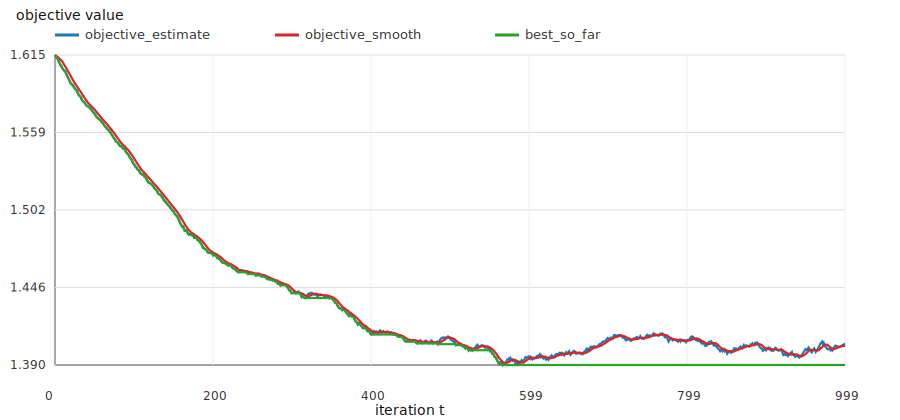

In [80]:
# Plot without matplotlib by generating a simple inline SVG.
def line_plot_svg(x, series_dict, width=900, height=420, margin=55):
    x = np.asarray(x, dtype=float)
    y_values = np.concatenate([np.asarray(y, dtype=float) for y in series_dict.values()])

    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y_values.min()), float(y_values.max())
    if math.isclose(ymin, ymax):
        ymax = ymin + 1.0

    def sx(xi):
        return margin + (xi - xmin) / (xmax - xmin) * (width - 2 * margin)

    def sy(yi):
        return height - margin - (yi - ymin) / (ymax - ymin) * (height - 2 * margin)

    palette = {
        'objective_estimate': '#1f77b4',
        'objective_smooth': '#d62728',
        'best_so_far': '#2ca02c',
    }

    svg = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<line x1="{margin}" y1="{height-margin}" x2="{width-margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
        f'<line x1="{margin}" y1="{margin}" x2="{margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
    ]

    for frac in np.linspace(0.0, 1.0, 5):
        y_tick = ymin + frac * (ymax - ymin)
        y_pos = sy(y_tick)
        svg.append(f'<line x1="{margin}" y1="{y_pos:.1f}" x2="{width-margin}" y2="{y_pos:.1f}" stroke="#dddddd" stroke-width="1"/>')
        svg.append(f'<text x="10" y="{y_pos+4:.1f}" font-size="12" fill="#333">{y_tick:.3f}</text>')

    for frac in np.linspace(0.0, 1.0, 6):
        x_tick = xmin + frac * (xmax - xmin)
        x_pos = sx(x_tick)
        svg.append(f'<line x1="{x_pos:.1f}" y1="{margin}" x2="{x_pos:.1f}" y2="{height-margin}" stroke="#eeeeee" stroke-width="1"/>')
        svg.append(f'<text x="{x_pos-10:.1f}" y="{height-20}" font-size="12" fill="#333">{int(round(x_tick))}</text>')

    for name, y in series_dict.items():
        pts = ' '.join(f'{sx(xi):.2f},{sy(yi):.2f}' for xi, yi in zip(x, y))
        color = palette.get(name, '#444444')
        svg.append(f'<polyline fill="none" stroke="{color}" stroke-width="2.2" points="{pts}"/>')

    legend_y = margin - 20
    legend_x = margin
    for idx, name in enumerate(series_dict):
        color = palette.get(name, '#444444')
        x0 = legend_x + idx * 220
        svg.append(f'<line x1="{x0}" y1="{legend_y}" x2="{x0+24}" y2="{legend_y}" stroke="{color}" stroke-width="3"/>')
        svg.append(f'<text x="{x0+30}" y="{legend_y+4}" font-size="13" fill="#333">{name}</text>')

    svg.append(f'<text x="{width/2-75:.1f}" y="{height-5}" font-size="14" fill="#111">iteration t</text>')
    svg.append(f'<text x="16" y="20" font-size="14" fill="#111">objective value</text>')
    svg.append('</svg>')
    return '\n'.join(svg)

plot_svg = line_plot_svg(
    history['t'].to_numpy(),
    {
        'objective_estimate': history['objective_estimate'].to_numpy(),
        'objective_smooth': history['objective_smooth'].to_numpy(),
        'best_so_far': history['best_so_far'].to_numpy(),
    },
)

display(SVG(plot_svg))

In [81]:
history.loc[:, ['t', 'objective_estimate', 'objective_smooth', 'best_so_far']].tail(10)

,t,objective_estimate,objective_smooth,best_so_far
990,990,1.402791,1.402300,1.389739
991,991,1.403037,1.402563,1.389739
992,992,1.403077,1.402756,1.389739
993,993,1.403368,1.403055,1.389739
994,994,1.403600,1.403246,1.389739
995,995,1.403789,1.403397,1.389739
996,996,1.404207,1.403489,1.389739
997,997,1.404235,1.403526,1.389739
998,998,1.404965,1.403650,1.389739
999,999,1.405344,1.403841,1.389739


## 2. Preprocessing and implementation notes

This notebook now matches the corrected basis description.

Preprocessing performed:

- Selected only the numeric columns needed by the four regression tasks.
- Renamed the original Ames columns with spaces into compact Python-friendly names.
- Coerced selected columns to numeric values.
- Imputed missing values in the selected columns with column medians.
- Standardized each task's predictors before forming the information matrices.
- Added a small ridge term to each information matrix so the log-determinant is numerically stable.

Implementation changes for the correction:

- `q = 2` basis functions are used per design point.
- `p = qd`, so `beta` is reshaped into `d x q` blocks.
- `Phi(lambda)` is treated implicitly as block-diagonal, which avoids explicitly materializing a huge `d x qd` matrix.
- The raw positive weights are normalized into a simplex vector `theta`, and the gradient uses the corresponding chain rule.

The evaluation budget is intentionally moderate so the notebook runs quickly on the full Ames dataset while still showing a clear decrease in the stochastic objective over iterations.

## 3. Downstream Task: Comparing Fixed and Adaptive $\gamma$ Schedules

This section leaves the earlier experiment untouched and adds two downstream comparisons.

1. A fixed-`\gamma` sweep with `\gamma \in \{10, 1, 0.1, 0.01\}` using the same initialization for `\beta`.
2. An adaptive-`\gamma` run that starts at `10`, detects a plateau, divides `\gamma` by `10`, and continues until reaching `0.01`.

Each experiment is saved to CSV. The final comparison plot reads those CSV files back from disk and overlays all five unregularized stochastic objective traces.


In [150]:
# Helper functions for the downstream gamma-comparison experiments.
gamma_values = [1e-1, 1e-2, 1e-3, 1e-4]
gamma_sweep_csv = "gamma_sweep_results.csv"
adaptive_gamma_csv = "adaptive_gamma_results.csv"

def eta_for_gamma(gamma_value):
    return 0.5 / (1.0 + gamma_value)


def estimated_stochastic_objective_for_gamma(beta, gamma_value):
    values = [sample_loss_and_grad(beta, lam)[0] for lam in eval_lambdas]
    no_reg = float(np.mean(values))
    reg = no_reg + float(gamma_value * psi(beta))
    return no_reg, reg


def mirror_step_for_gamma(beta, grad_f, gamma_value):
    eta_value = eta_for_gamma(gamma_value)
    v = eta_value * grad_f - (1.0 - eta_value * gamma_value) * grad_psi(beta)
    xi = solve_xi(v)
    beta_next = 1.0 / (v + xi)
    beta_next = np.clip(beta_next, 1e-15, None)
    beta_next = beta_next / beta_next.sum()
    return beta_next


def run_fixed_gamma_experiment(gamma_value, beta_init, lambda_sequence):
    beta = beta_init.copy()
    rows = []
    for t, lam_t in enumerate(lambda_sequence):
        sample_loss, grad_f = sample_loss_and_grad(beta, lam_t)
        no_reg_obj, reg_obj = estimated_stochastic_objective_for_gamma(beta, gamma_value)
        rows.append({
            "experiment": f"fixed gamma={gamma_value:g}",
            "mode": "fixed",
            "gamma": gamma_value,
            "phase": np.nan,
            "phase_iteration": np.nan,
            "t": t,
            "objective_estimate": no_reg_obj,
            "reg_objective_estimate": reg_obj,
            "sample_loss": sample_loss,
            "beta_min": beta.min(),
            "beta_max": beta.max(),
        })
        beta = mirror_step_for_gamma(beta, grad_f, gamma_value)
    return pd.DataFrame(rows)


def plateau_detected(values, patience=12, tol=1e-3):
    if len(values) < 2 * patience:
        return False
    previous_best = min(values[-2 * patience:-patience])
    recent_best = min(values[-patience:])
    return (previous_best - recent_best) < tol


def run_adaptive_gamma_experiment(beta_init, gamma_start=1e-1, gamma_end=1e-5, max_phase_iters=200):
    beta = beta_init.copy()
    current_gamma = gamma_start
    phase = 0
    t_global = 0
    rows = []
    rng_adaptive = np.random.default_rng(SEED + 2026)

    while current_gamma >= gamma_end - 1e-12:
        phase_reg_objectives = []
        for phase_iteration in range(max_phase_iters):
            lam_t = sample_lambda(rng_adaptive)
            sample_loss, grad_f = sample_loss_and_grad(beta, lam_t)
            no_reg_obj, reg_obj = estimated_stochastic_objective_for_gamma(beta, current_gamma)
            phase_reg_objectives.append(reg_obj)
            rows.append({
                "experiment": "adaptive gamma",
                "mode": "adaptive",
                "gamma": current_gamma,
                "phase": phase,
                "phase_iteration": phase_iteration,
                "t": t_global,
                "objective_estimate": no_reg_obj,
                "reg_objective_estimate": reg_obj,
                "sample_loss": sample_loss,
                "beta_min": beta.min(),
                "beta_max": beta.max(),
            })
            beta = mirror_step_for_gamma(beta, grad_f, current_gamma)
            t_global += 1
            
            temp = int(-np.log10(current_gamma))
            if phase_iteration + 1 >= 24 and plateau_detected(phase_reg_objectives, patience= temp + 5, tol=0.1 * 0.5**temp):
                break

        if current_gamma <= gamma_end + 1e-12:
            break
        current_gamma = max(current_gamma / 10.0, gamma_end)
        phase += 1

    return pd.DataFrame(rows)


In [137]:
# Run the four fixed-gamma experiments and save them.
beta_init = np.full(p, 1.0 / p)
rng_fixed = np.random.default_rng(SEED + 314159)
fixed_lambda_sequence = [sample_lambda(rng_fixed) for _ in range(T)]

gamma_sweep_results = pd.concat(
    [run_fixed_gamma_experiment(gamma_value, beta_init, fixed_lambda_sequence) for gamma_value in gamma_values],
    ignore_index=True,
)
gamma_sweep_results.to_csv(gamma_sweep_csv, index=False)
gamma_sweep_results.head()


,experiment,mode,gamma,phase,phase_iteration,t,objective_estimate,reg_objective_estimate,sample_loss,beta_min,beta_max
0,fixed gamma=0.1,fixed,0.1,NaN,NaN,0,1.615171,64335.566428,1.668848,0.000017,0.000017
1,fixed gamma=0.1,fixed,0.1,NaN,NaN,1,1.614387,64335.565661,1.328505,0.000017,0.000017
2,fixed gamma=0.1,fixed,0.1,NaN,NaN,2,1.613181,64335.564548,1.746764,0.000017,0.000017
3,fixed gamma=0.1,fixed,0.1,NaN,NaN,3,1.612443,64335.563904,1.373647,0.000017,0.000017
4,fixed gamma=0.1,fixed,0.1,NaN,NaN,4,1.611289,64335.562965,1.489406,0.000017,0.000018


In [163]:
# Run the adaptive-gamma experiment and save it separately.
adaptive_gamma_results = run_adaptive_gamma_experiment(beta_init, gamma_start=1e-1, gamma_end=1e-6, max_phase_iters=200)
adaptive_gamma_results.to_csv(adaptive_gamma_csv, index=False)
adaptive_gamma_results.head()


,experiment,mode,gamma,phase,phase_iteration,t,objective_estimate,reg_objective_estimate,sample_loss,beta_min,beta_max
0,adaptive gamma,adaptive,0.1,0,0,0,1.615171,64335.566428,1.512595,0.000017,0.000017
1,adaptive gamma,adaptive,0.1,0,1,1,1.614194,64335.565480,1.460324,0.000017,0.000017
2,adaptive gamma,adaptive,0.1,0,2,2,1.613126,64335.564498,1.417790,0.000017,0.000017
3,adaptive gamma,adaptive,0.1,0,3,3,1.612063,64335.563590,1.654021,0.000017,0.000017
4,adaptive gamma,adaptive,0.1,0,4,4,1.611320,64335.562984,1.825176,0.000017,0.000017


In [164]:
# Read the saved CSV files back from disk and prepare a joint comparison table.
gamma_sweep_from_csv = pd.read_csv(gamma_sweep_csv)
adaptive_gamma_from_csv = pd.read_csv(adaptive_gamma_csv)

comparison_results = pd.concat([gamma_sweep_from_csv, adaptive_gamma_from_csv], ignore_index=True)
comparison_results["objective_smooth"] = comparison_results.groupby("experiment")["objective_estimate"].transform(
    lambda s: s.rolling(20, min_periods=1).mean()
)

comparison_results.groupby("experiment")["objective_estimate"].agg(["first", "last", "min"])


,first,last,min
experiment,,,
adaptive gamma,1.615171,-0.324360,-0.324360
fixed gamma=0.0001,1.615171,-1.293694,-1.294252
fixed gamma=0.001,1.615171,0.166346,0.147538
fixed gamma=0.01,1.615171,1.403346,1.393351
fixed gamma=0.1,1.615171,1.596502,1.592368


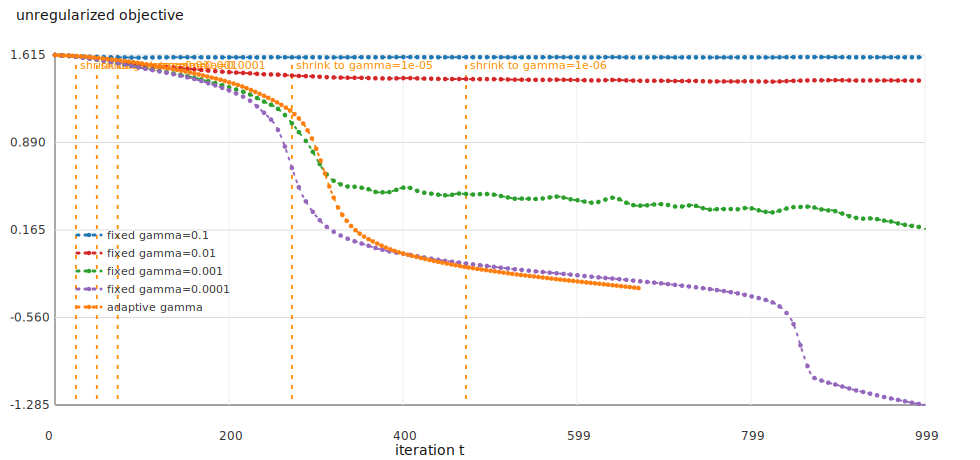

In [172]:
# Plot all five experiments together using the unregularized stochastic objective.
def multi_experiment_svg(df, value_col="objective_estimate", width=980, height=460, margin=55):
    labels = list(df["experiment"].unique())
    y_values = df[value_col].to_numpy(dtype=float)
    x_max = float(df["t"].max())
    y_min = float(y_values.min())
    y_max = float(y_values.max())
    if math.isclose(y_min, y_max):
        y_max = y_min + 1.0

    def sx(xi):
        return margin + xi / max(x_max, 1.0) * (width - 2 * margin)

    def sy(yi):
        return height - margin - (yi - y_min) / (y_max - y_min) * (height - 2 * margin)

    palette = {
        "fixed gamma=0.1": "#1f77b4",
        "fixed gamma=0.01": "#d62728",
        "fixed gamma=0.001": "#2ca02c",
        "fixed gamma=0.0001": "#9467bd",
        "adaptive gamma": "#ff7f0e",
    }

    svg = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<line x1="{margin}" y1="{height-margin}" x2="{width-margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
        f'<line x1="{margin}" y1="{margin}" x2="{margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
    ]

    for frac in np.linspace(0.0, 1.0, 5):
        y_tick = y_min + frac * (y_max - y_min)
        y_pos = sy(y_tick)
        svg.append(f'<line x1="{margin}" y1="{y_pos:.1f}" x2="{width-margin}" y2="{y_pos:.1f}" stroke="#dddddd" stroke-width="1"/>')
        svg.append(f'<text x="10" y="{y_pos+4:.1f}" font-size="12" fill="#333">{y_tick:.3f}</text>')

    for frac in np.linspace(0.0, 1.0, 6):
        x_tick = frac * x_max
        x_pos = sx(x_tick)
        svg.append(f'<line x1="{x_pos:.1f}" y1="{margin}" x2="{x_pos:.1f}" y2="{height-margin}" stroke="#eeeeee" stroke-width="1"/>')
        svg.append(f'<text x="{x_pos-10:.1f}" y="{height-20}" font-size="12" fill="#333">{int(round(x_tick))}</text>')

    adaptive_frame = df[df["experiment"] == "adaptive gamma"].sort_values("t")
    if "phase" in adaptive_frame.columns and not adaptive_frame.empty:
        phase_starts = adaptive_frame.groupby("phase", dropna=True).first().reset_index()
        for _, row in phase_starts.iloc[1:].iterrows():
            x_phase = sx(float(row["t"]))
            svg.append(f'<line x1="{x_phase:.2f}" y1="{margin}" x2="{x_phase:.2f}" y2="{height-margin}" stroke="#ff8c00" stroke-width="1.8" stroke-dasharray="4,6"/>')
            svg.append(f'<text x="{x_phase+4:.2f}" y="{margin+14:.2f}" font-size="11" fill="#ff8c00">shrink to gamma={row["gamma"]:g}</text>')

    for label in labels:
        frame = df[df["experiment"] == label].sort_values("t")
        pts = " ".join(f"{sx(xi):.2f},{sy(yi):.2f}" for xi, yi in zip(frame["t"], frame[value_col]))
        color = palette.get(label, "#444444")
        svg.append(f'<polyline fill="none" stroke="{color}" stroke-width="2.0" stroke-dasharray="2,6" stroke-linecap="round" points="{pts}"/>')

        marker_step = max(1, len(frame) // 120)
        for xi, yi in zip(frame["t"].iloc[::marker_step], frame[value_col].iloc[::marker_step]):
            svg.append(f'<circle cx="{sx(xi):.2f}" cy="{sy(yi):.2f}" r="2.3" fill="{color}"/>')

    # legend_y = margin - 20
    # legend_x = margin
    # for idx, label in enumerate(labels):
    #     color = palette.get(label, "#444444")
    #     x0 = legend_x + idx * 175
    #     svg.append(f'<line x1="{x0}" y1="{legend_y}" x2="{x0+24}" y2="{legend_y}" stroke="{color}" stroke-width="3" stroke-dasharray="2,6" stroke-linecap="round"/>')
    #     svg.append(f'<circle cx="{x0+12}" cy="{legend_y}" r="2.4" fill="{color}"/>')
    #     svg.append(f'<text x="{x0+30}" y="{legend_y+4}" font-size="13" fill="#333">{label}</text>')
    legend_x = margin + 22
    legend_y = margin + 180
    legend_gap = 18
    for idx, label in enumerate(labels):
        color = palette.get(label, "#444444")
        y0 = legend_y + idx * legend_gap
        svg.append(f'<line x1="{legend_x}" y1="{y0}" x2="{legend_x+24}" y2="{y0}" stroke="{color}" stroke-width="3" stroke-dasharray="2,6" stroke-linecap="round"/>')
        svg.append(f'<circle cx="{legend_x+12}" cy="{y0}" r="2.2" fill="{color}"/>')
        svg.append(f'<text x="{legend_x+30}" y="{y0+4}" font-size="11" fill="#333">{label}</text>')

    svg.append(f'<text x="{width/2-95:.1f}" y="{height-5}" font-size="14" fill="#111">iteration t</text>')
    svg.append(f'<text x="16" y="20" font-size="14" fill="#111">unregularized objective</text>')
    svg.append('</svg>')
    return "\n".join(svg)

display(SVG(multi_experiment_svg(comparison_results, value_col="objective_smooth")))


## 4. Mean-$\lambda$ Benchmark Line

Because `h(\theta, \lambda)` is linear in `\lambda`, replacing `\lambda` by its mean gives a deterministic weighted objective in `\theta`. This section now uses a Newton-type method, specifically a limited-memory BFGS solver on a softmax parameterization of `\theta`, to compute a sharper deterministic benchmark. The resulting best attained value is plotted as a grey horizontal reference line.


In [97]:
# Deterministic theta-space benchmark using a Newton-type solver (L-BFGS) with mean lambda.
theta_reference_csv = "theta_mean_lambda_reference_results.csv"
lambda_mean = np.full(S, 1.0 / S)


def softmax_theta(z):
    z_shifted = z - np.max(z)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum()


def mean_lambda_theta_objective_and_grad(theta):
    objective = 0.0
    grad_theta = np.zeros(d)
    for s, X in enumerate(X_list):
        M = information_matrix(X, theta)
        sign, logdet = np.linalg.slogdet(M)
        if sign <= 0:
            raise RuntimeError("Encountered a non-positive determinant in the theta-space mean-lambda benchmark.")
        objective += lambda_mean[s] * (-logdet)
        M_inv = np.linalg.inv(M)
        XM_inv = X @ M_inv
        diag_A_s = np.sum(XM_inv * X, axis=1)
        grad_theta += lambda_mean[s] * (-diag_A_s)
    return float(objective), grad_theta


def theta_objective_from_z(z):
    theta = softmax_theta(z)
    objective, grad_theta = mean_lambda_theta_objective_and_grad(theta)
    centered_grad = grad_theta - np.dot(theta, grad_theta)
    grad_z = theta * centered_grad
    return objective, grad_z, theta


def lbfgs_direction(grad, s_hist, y_hist):
    if not s_hist:
        return -grad

    q_vec = grad.copy()
    alpha_vals = []
    rho_vals = []

    for s_vec, y_vec in zip(reversed(s_hist), reversed(y_hist)):
        rho = 1.0 / np.dot(y_vec, s_vec)
        alpha = rho * np.dot(s_vec, q_vec)
        rho_vals.append(rho)
        alpha_vals.append(alpha)
        q_vec = q_vec - alpha * y_vec

    last_s = s_hist[-1]
    last_y = y_hist[-1]
    scale = np.dot(last_s, last_y) / np.dot(last_y, last_y)
    r_vec = scale * q_vec

    for s_vec, y_vec, rho, alpha in zip(s_hist, y_hist, reversed(rho_vals), reversed(alpha_vals)):
        beta = rho * np.dot(y_vec, r_vec)
        r_vec = r_vec + s_vec * (alpha - beta)

    return -r_vec


def run_mean_lambda_lbfgs(max_iters=80, memory=8, c1=1e-4, backtrack=0.5):
    z = np.zeros(d)
    objective, grad_z, theta = theta_objective_from_z(z)
    s_hist = []
    y_hist = []
    rows = []

    for t_theta in range(max_iters):
        grad_norm = float(np.linalg.norm(grad_z))
        rows.append({
            "t": t_theta,
            "mean_lambda_theta_objective": objective,
            "grad_norm": grad_norm,
        })

        direction = lbfgs_direction(grad_z, s_hist, y_hist)
        if np.dot(direction, grad_z) >= 0:
            direction = -grad_z

        step = 1.0
        while step > 1e-8:
            z_candidate = z + step * direction
            objective_candidate, grad_candidate, theta_candidate = theta_objective_from_z(z_candidate)
            if objective_candidate <= objective + c1 * step * np.dot(grad_z, direction):
                break
            step *= backtrack

        if step <= 1e-8:
            break

        s_vec = z_candidate - z
        y_vec = grad_candidate - grad_z
        sy = float(np.dot(s_vec, y_vec))
        if sy > 1e-12:
            s_hist.append(s_vec)
            y_hist.append(y_vec)
            if len(s_hist) > memory:
                s_hist.pop(0)
                y_hist.pop(0)

        z = z_candidate
        objective = objective_candidate
        grad_z = grad_candidate
        theta = theta_candidate

        if grad_norm < 1e-7:
            rows.append({
                "t": t_theta + 1,
                "mean_lambda_theta_objective": objective,
                "grad_norm": float(np.linalg.norm(grad_z)),
            })
            break

    return pd.DataFrame(rows), theta, z


theta_reference_results, theta_reference, z_reference = run_mean_lambda_lbfgs(max_iters=80, memory=8)
theta_reference_results.to_csv(theta_reference_csv, index=False)
theta_reference_level = float(theta_reference_results["mean_lambda_theta_objective"].min())
theta_reference_results.head()


,t,mean_lambda_theta_objective,grad_norm
0,0,1.612155,0.179820
1,1,1.579203,0.186795
2,2,1.543597,0.194574
3,3,1.504902,0.203329
4,4,1.462569,0.213277


In [98]:
theta_reference_level

-7.004132930830053

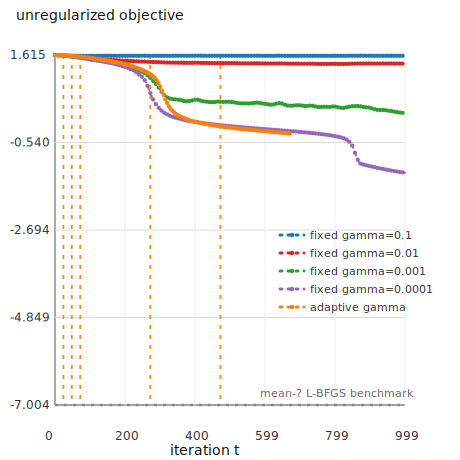

In [173]:
# Plot the existing five experiments together with the grey mean-lambda L-BFGS benchmark line.
theta_reference_from_csv = pd.read_csv(theta_reference_csv)
theta_reference_level = float(theta_reference_from_csv["mean_lambda_theta_objective"].min())

def multi_experiment_with_reference_svg(df, reference_level, value_col="objective_estimate", width=460, height=460, margin=55):
    labels = list(df["experiment"].unique())
    y_values = np.concatenate([df[value_col].to_numpy(dtype=float), np.array([reference_level])])
    x_max = float(df["t"].max())
    y_min = float(y_values.min())
    y_max = float(y_values.max())
    if math.isclose(y_min, y_max):
        y_max = y_min + 1.0

    def sx(xi):
        return margin + xi / max(x_max, 1.0) * (width - 2 * margin)

    def sy(yi):
        return height - margin - (yi - y_min) / (y_max - y_min) * (height - 2 * margin)

    palette = {
        "fixed gamma=0.1": "#1f77b4",
        "fixed gamma=0.01": "#d62728",
        "fixed gamma=0.001": "#2ca02c",
        "fixed gamma=0.0001": "#9467bd",
        "adaptive gamma": "#ff7f0e",
    }

    svg = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
        f'<line x1="{margin}" y1="{height-margin}" x2="{width-margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
        f'<line x1="{margin}" y1="{margin}" x2="{margin}" y2="{height-margin}" stroke="#333" stroke-width="1.5"/>',
    ]

    for frac in np.linspace(0.0, 1.0, 5):
        y_tick = y_min + frac * (y_max - y_min)
        y_pos = sy(y_tick)
        svg.append(f'<line x1="{margin}" y1="{y_pos:.1f}" x2="{width-margin}" y2="{y_pos:.1f}" stroke="#dddddd" stroke-width="1"/>')
        svg.append(f'<text x="10" y="{y_pos+4:.1f}" font-size="12" fill="#333">{y_tick:.3f}</text>')

    for frac in np.linspace(0.0, 1.0, 6):
        x_tick = frac * x_max
        x_pos = sx(x_tick)
        svg.append(f'<line x1="{x_pos:.1f}" y1="{margin}" x2="{x_pos:.1f}" y2="{height-margin}" stroke="#eeeeee" stroke-width="1"/>')
        svg.append(f'<text x="{x_pos-10:.1f}" y="{height-20}" font-size="12" fill="#333">{int(round(x_tick))}</text>')

    adaptive_frame = df[df["experiment"] == "adaptive gamma"].sort_values("t")
    if "phase" in adaptive_frame.columns and not adaptive_frame.empty:
        phase_starts = adaptive_frame.groupby("phase", dropna=True).first().reset_index()
        for _, row in phase_starts.iloc[1:].iterrows():
            x_phase = sx(float(row["t"]))
            svg.append(f'<line x1="{x_phase:.2f}" y1="{margin}" x2="{x_phase:.2f}" y2="{height-margin}" stroke="#ff8c00" stroke-width="1.8" stroke-dasharray="4,6"/>')

    y_ref = sy(reference_level)
    svg.append(f'<line x1="{margin}" y1="{y_ref:.2f}" x2="{width-margin}" y2="{y_ref:.2f}" stroke="#888888" stroke-width="2.5" stroke-dasharray="3,6"/>')
    svg.append(f'<text x="{max(margin + 6, width - margin - 145):.2f}" y="{y_ref-8:.2f}" font-size="11" fill="#666666">mean-? L-BFGS benchmark</text>')

    for label in labels:
        frame = df[df["experiment"] == label].sort_values("t")
        pts = " ".join(f"{sx(xi):.2f},{sy(yi):.2f}" for xi, yi in zip(frame["t"], frame[value_col]))
        color = palette.get(label, "#444444")
        svg.append(f'<polyline fill="none" stroke="{color}" stroke-width="2.0" stroke-dasharray="2,6" stroke-linecap="round" points="{pts}"/>')

        marker_step = max(1, len(frame) // 120)
        for xi, yi in zip(frame["t"].iloc[::marker_step], frame[value_col].iloc[::marker_step]):
            svg.append(f'<circle cx="{sx(xi):.2f}" cy="{sy(yi):.2f}" r="2.1" fill="{color}"/>')

    legend_x = width - 180
    legend_y = margin + 180
    legend_gap = 18
    for idx, label in enumerate(labels):
        color = palette.get(label, "#444444")
        y0 = legend_y + idx * legend_gap
        svg.append(f'<line x1="{legend_x}" y1="{y0}" x2="{legend_x+24}" y2="{y0}" stroke="{color}" stroke-width="3" stroke-dasharray="2,6" stroke-linecap="round"/>')
        svg.append(f'<circle cx="{legend_x+12}" cy="{y0}" r="2.2" fill="{color}"/>')
        svg.append(f'<text x="{legend_x+30}" y="{y0+4}" font-size="11" fill="#333">{label}</text>')

    svg.append(f'<text x="{width/2-60:.1f}" y="{height-5}" font-size="14" fill="#111">iteration t</text>')
    svg.append(f'<text x="16" y="20" font-size="14" fill="#111">unregularized objective</text>')
    svg.append('</svg>')
    return "\n".join(svg)

display(SVG(multi_experiment_with_reference_svg(comparison_results, theta_reference_level, value_col="objective_smooth")))
